# 05 — QTAIM analysis

Validate QTAIM topology and compare global and matched bond-critical-point descriptors in the shared PDI framework.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    }
)


def style_white_axes(fig, ax):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_color("black")


ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
FIGURES = ROOT / "figures"
SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Functionalized PDI",
}

SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}

In [2]:
qtaim_cps = pd.read_csv(RESULTS / "qtaim" / "critical_points.csv")
qtaim_props = pd.read_csv(RESULTS / "qtaim" / "critical_point_properties.csv")

QTAIM_FIGURES = FIGURES / "qtaim"
QTAIM_FIGURES.mkdir(parents=True, exist_ok=True)

qtaim = qtaim_cps.merge(
    qtaim_props,
    on=["system", "cp_index"],
    how="left",
    suffixes=("", "_property"),
    validate="one_to_one",
)

display(qtaim.head())


,system,source_file,cp_index,signature,cp_type,line,x,y,z,raw_line,...,norm_of_gradient_is,total,eigenvalues_of_hessian,determinant_of_hessian,ellipticity_of_electron_density,eta_index,stiffness,eigenvalues_of_stress_tensor,stress_tensor_stiffness,stress_tensor_polarizability
0,pdi,calculations/pdi/multiwfn_analysis/ground_stat...,1,"(3,-3)",nuclear,2,-6.464908,-6.300677,-0.059120,1 -6.464908 -6.300677 -0.059120 1,...,3.836544e-15,-2.583207e+01,-8.095806e+00,-6.366845e+02,0.000609,-1.095732,-1.095064,-2.026122,1.096881,0.911676
1,pdi,calculations/pdi/multiwfn_analysis/ground_stat...,2,"(3,-3)",nuclear,3,-1.859007,-6.373345,-0.047475,2 -1.859007 -6.373345 -0.047475 1,...,9.104604e-16,-2.635277e+01,-8.284498e+00,-6.761439e+02,0.000660,-1.090846,-1.090127,-2.073546,1.091997,0.915754
2,pdi,calculations/pdi/multiwfn_analysis/ground_stat...,3,"(3,-3)",nuclear,4,1.839832,-6.375990,-0.071115,3 1.839832 -6.375990 -0.071115 1,...,5.389987e-16,-2.635259e+01,-8.284436e+00,-6.761300e+02,0.000660,-1.090848,-1.090128,-2.073531,1.091998,0.915753
3,pdi,calculations/pdi/multiwfn_analysis/ground_stat...,4,"(3,-3)",nuclear,5,-10.781177,-4.285321,-0.051076,4 -10.781177 -4.285321 -0.051076 1,...,7.380359e-10,-4.527211e+06,-1.509050e+06,-3.436595e+18,0.000002,-1.000021,-1.000018,-377314.785600,1.000021,0.999979
4,pdi,calculations/pdi/multiwfn_analysis/ground_stat...,5,"(3,-3)",nuclear,6,6.445833,-6.310575,-0.059108,5 6.445833 -6.310575 -0.059108 1,...,2.626911e-15,-2.583224e+01,-8.095861e+00,-6.366968e+02,0.000609,-1.095731,-1.095064,-2.026136,1.096881,0.911676


In [3]:
assert set(qtaim_cps["system"]) == set(SYSTEM_ORDER)
assert not qtaim_cps.duplicated(["system", "cp_index"]).any()

cp_counts = qtaim_cps.groupby(["system", "cp_type"]).size().rename("count").reset_index()
cp_counts.pivot(index="cp_type", columns="system", values="count").fillna(0).astype(int)


system,pdi,pdi_terminal_functionalized
cp_type,,
bond,48,84
nuclear,40,70
ring,9,15


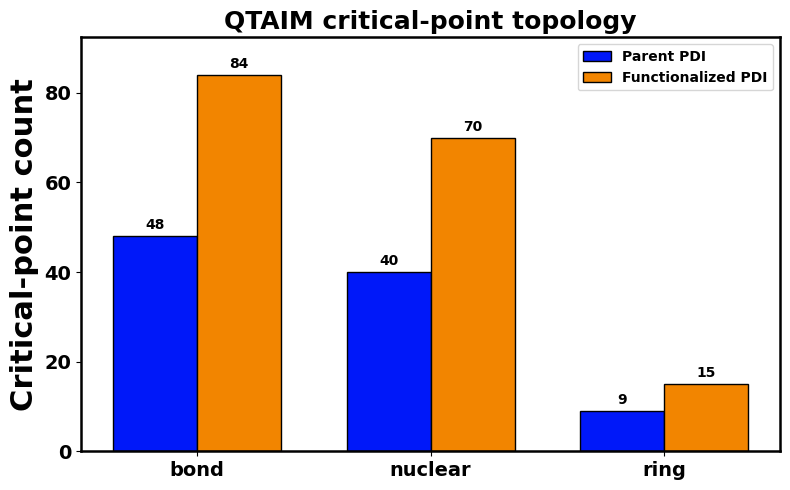

In [4]:
counts_pivot = cp_counts.pivot(index="cp_type", columns="system", values="count").fillna(0).astype(int)

fig, ax = plt.subplots(facecolor="white", figsize=(8, 5))
x = np.arange(len(counts_pivot.index), dtype=float)
width = 0.36
bar_containers = []

for offset, system in zip([-width / 2, width / 2], SYSTEM_ORDER, strict=True):
    vals = (
        counts_pivot[system]
        if system in counts_pivot.columns
        else pd.Series(0, index=counts_pivot.index)
    )
    bars = ax.bar(
    x + offset,
    vals,
    width=width,
    label=SYSTEM_LABELS[system],
    color=SYSTEM_COLORS[system],
    edgecolor="black",
)
    bar_containers.append(bars)

max_count = max((bar.get_height() for bars in bar_containers for bar in bars), default=0)
ax.set_ylim(0, max_count + max(1.0, 0.10 * max_count))

for bars in bar_containers:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            clip_on=False,
        )

ax.set_xticks(x)
ax.set_xticklabels(counts_pivot.index)
ax.set_ylabel("Critical-point count", fontsize=22, fontweight="bold")
ax.set_title("QTAIM critical-point topology", fontsize=18, fontweight="bold")
ax.legend(frameon=True, prop={"size": 10, "weight": "bold"})
# ax.spines[["top", "right"]].set_visible(False)

style_white_axes(fig, ax)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
    tick_label.set_fontsize(14)
    tick_label.set_fontweight("bold")

fig.tight_layout()

fig.savefig(QTAIM_FIGURES / "critical_point_counts.pdf", bbox_inches="tight")
fig.savefig(QTAIM_FIGURES / "critical_point_counts.png", dpi=300, bbox_inches="tight")

plt.show()


In [5]:
# Poincaré–Hopf topology validation:
# N_nuclear - N_bond + N_ring - N_cage = 1

topology_rows = []

for system in SYSTEM_ORDER:
    counts = (
        qtaim_cps.loc[qtaim_cps["system"] == system, "cp_type"]
        .astype(str)
        .str.lower()
        .value_counts()
        .to_dict()
    )

    nuclear_count = int(counts.get("nuclear", 0))
    bond_count = int(counts.get("bond", 0))
    ring_count = int(counts.get("ring", 0))
    cage_count = int(counts.get("cage", 0))

    poincare_hopf_value = (
        nuclear_count
        - bond_count
        + ring_count
        - cage_count
    )

    topology_rows.append(
        {
            "system": system,
            "system_label": SYSTEM_LABELS[system],
            "nuclear_cp": nuclear_count,
            "bond_cp": bond_count,
            "ring_cp": ring_count,
            "cage_cp": cage_count,
            "poincare_hopf_value": poincare_hopf_value,
            "passes": poincare_hopf_value == 1,
        }
    )

topology_check = pd.DataFrame(topology_rows)

assert topology_check["passes"].all(), (
    "At least one system does not satisfy the Poincaré–Hopf "
    "relationship. Inspect the parsed critical points."
)

topology_check.to_csv(
    RESULTS / "qtaim" / "topology_check.csv",
    index=False,
)

display(topology_check)

,system,system_label,nuclear_cp,bond_cp,ring_cp,cage_cp,poincare_hopf_value,passes
0,pdi,Parent PDI,40,48,9,0,1,True
1,pdi_terminal_functionalized,Functionalized PDI,70,84,15,0,1,True


**In data extraction, the Poincaré–Hopf topology validation can be summarized in a table.**

In [6]:
candidate_columns = [
    "density_of_all_electrons",
    "laplacian_of_electron_density",
    "lagrangian_kinetic_energy_g_r",
    "hamiltonian_kinetic_energy_k_r",
    "potential_energy_density_v_r",
    "energy_density_e_r_or_h_r",
    "ellipticity_of_electron_density",
    "electron_localization_function_elf",
    "localized_orbital_locator_lol",
    "sign_lambda2_rho",
]
available = [c for c in candidate_columns if c in qtaim.columns]
bond_cps = qtaim[qtaim["cp_type"].astype(str).str.lower() == "bond"].copy()

for c in available:
    bond_cps[c] = pd.to_numeric(bond_cps[c], errors="coerce")

bond_cps.groupby("system")[available].agg(["count", "mean", "median", "min", "max"])


density_of_all_electrons                      \
                                               count      mean    median   
system                                                                     
pdi                                               48  0.302042  0.307185   
pdi_terminal_functionalized                       84  0.267598  0.282468   

                                                laplacian_of_electron_density  \
                                  min       max                         count   
system                                                                          
pdi                          0.014500  0.418991                            48   
pdi_terminal_functionalized  0.012592  0.415979                            84   

                                                                     ...  \
                                 mean    median       min       max  ...   
system                                                               ...   
pdi                         -0.885756 -0.929244 -1.826633  0.052721  ...   
pdi_terminal_functionalized -0.780080 -0.931818 -1.053032  0.098467  ...   

                            localized_orbital_locator_lol                      \
                                                    count      mean    median   
system                                                                          
pdi                                                    48  0.770106  0.810063   
pdi_terminal_functionalized                            84  0.759666  0.829116   

                                                sign_lambda2_rho            \
                                  min       max            count      mean   
system                                                                       
pdi                          0.181106  0.915343               48 -0.302042   
pdi_terminal_functionalized  0.153755  0.915249               84 -0.267598   

                                                           
                               median       min       max  
system                                                     
pdi                         -0.307185 -0.418991 -0.014500  
pdi_terminal_functionalized -0.282468 -0.415979 -0.012592  

[2 rows x 50 columns]

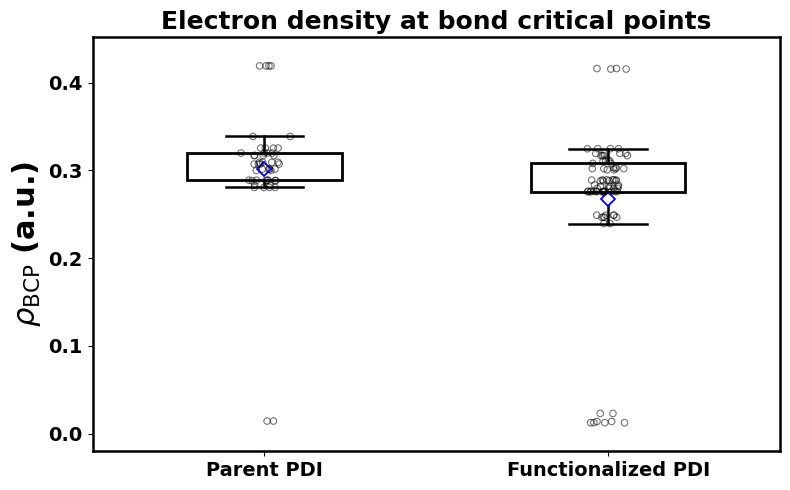

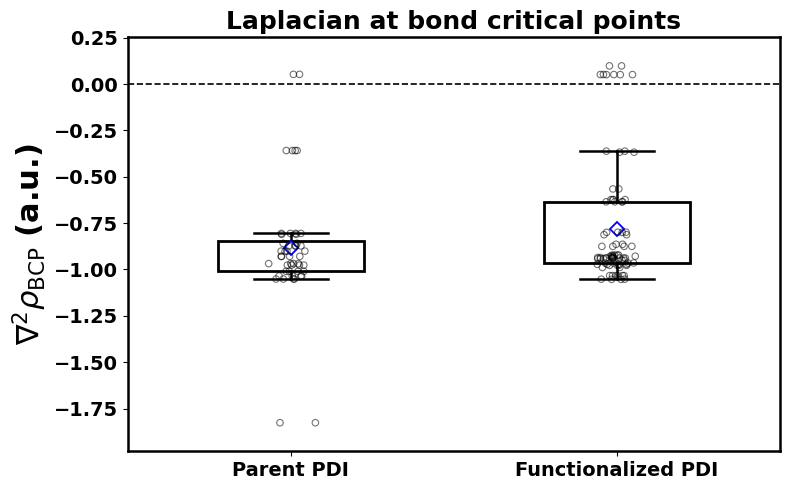

In [7]:
for column, ylabel, title, filename in [
    (
        "density_of_all_electrons",
        r"$\rho_\mathrm{BCP}$ (a.u.)",
        "Electron density at bond critical points",
        "bcp_electron_density_distribution",
    ),
    (
        "laplacian_of_electron_density",
        r"$\nabla^2\rho_\mathrm{BCP}$ (a.u.)",
        "Laplacian at bond critical points",
        "bcp_laplacian_distribution",
    ),
]:
    if column not in bond_cps.columns:
        continue

    fig, ax = plt.subplots(facecolor="white", figsize=(8, 5))
    grouped = [
        bond_cps.loc[bond_cps["system"] == system, column].dropna().to_numpy()
        for system in SYSTEM_ORDER
    ]
    positions = np.arange(1, len(SYSTEM_ORDER) + 1)

    rng = np.random.default_rng(42)

    box = ax.boxplot(
    grouped,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showmeans=True,
    showfliers=False,
    whis=1.5,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 2.0,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.8,
    },
    capprops={
        "color": "black",
        "linewidth": 1.8,
    },
    medianprops={
        "color": "red",
        "linewidth": 0,
    },
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "blue",
        "markeredgewidth": 1.3,
        "markersize": 7,
    },
)

    for x_position, values in zip(positions, grouped, strict=True):
        finite_values = values[np.isfinite(values)]
        jitter = rng.normal(
        loc=0.0,
        scale=0.035,
        size=len(finite_values),
    )

        ax.scatter(
        np.full(len(finite_values), x_position, dtype=float) + jitter,
        finite_values,
        s=22,
        facecolors="none",
        edgecolors="black",
        linewidths=0.8,
        alpha=0.55,
        zorder=3,
    )
        ax.set_xticks(positions)
        ax.set_xticklabels([SYSTEM_LABELS[system] for system in SYSTEM_ORDER])

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(14)
        tick_label.set_fontweight("bold")

    if column == "laplacian_of_electron_density":
        ax.axhline(0, color="black", linewidth=1.2, ls="--")

    # Automatically zoom to the actual data range
    all_values = np.concatenate(grouped)

    lower = np.nanmin(all_values)
    upper = np.nanmax(all_values)
    padding = 0.08 * (upper - lower)

    ax.set_ylim(lower - padding, upper + padding)

    ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    ax.set_title(title, fontsize=18, fontweight="bold")
    #ax.spines[["top", "right"]].set_visible(False)
    style_white_axes(fig, ax)

    fig.tight_layout()
    fig.savefig(QTAIM_FIGURES / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(QTAIM_FIGURES / f"{filename}.png", dpi=300, bbox_inches="tight")

    plt.show()


## Matched bond-critical-point comparison

The global BCP distribution plots above compare the full bond-critical-point populations. The parent and terminal-functionalized systems do not have the same total bond population, so those plots should not be interpreted as direct evidence that the shared PDI core is uniformly strengthened or weakened. The matched analysis below isolates chemically corresponding heavy-atom bonds in the shared PDI framework using the validated atom mapping and selected-bond workflow from the Mayer bond-order analysis.


In [8]:
ATOM_MAPPING_FILE = ROOT / "config" / "pdi_core_atom_mapping.csv"
SELECTED_BONDS_FILE = ROOT / "config" / "selected_bonds_candidates.csv"
XYZ_FILES = {
    "pdi": ROOT / "calculations" / "pdi" / "electronic_structure_calculation" / "pdi_opt.xyz",
    "pdi_terminal_functionalized": ROOT
    / "calculations"
    / "pdi_terminal_functionalized"
    / "electronic_structure_calculation"
    / "pdi_terminal_functionalized_opt.xyz",
}

atom_mapping = pd.read_csv(ATOM_MAPPING_FILE)
selected_bonds = pd.read_csv(SELECTED_BONDS_FILE)


def read_xyz_table(path: Path) -> pd.DataFrame:
    lines = path.read_text(encoding="utf-8").splitlines()
    atom_count = int(lines[0].strip())
    coordinate_lines = lines[2 : 2 + atom_count]

    if len(coordinate_lines) != atom_count:
        raise ValueError(f"XYZ atom-count mismatch in {path}")

    rows = []
    for atom_index, line in enumerate(coordinate_lines, start=1):
        fields = line.split()
        rows.append(
            {
                "atom": atom_index,
                "element": fields[0],
                "x": float(fields[1]),
                "y": float(fields[2]),
                "z": float(fields[3]),
            }
        )

    return pd.DataFrame(rows)


def normalize_pair_values(atom_i: int, atom_j: int) -> tuple[int, int]:
    return tuple(sorted((int(atom_i), int(atom_j))))


def bond_length(
    xyz_by_system: dict[str, pd.DataFrame],
    system: str,
    atom_i: int,
    atom_j: int,
) -> float:
    coordinates = xyz_by_system[system].set_index("atom")[["x", "y", "z"]]
    vector = coordinates.loc[int(atom_i)].to_numpy() - coordinates.loc[int(atom_j)].to_numpy()
    return float(np.linalg.norm(vector))


xyz_by_system = {system: read_xyz_table(path) for system, path in XYZ_FILES.items()}

mapping_with_pairs = atom_mapping.dropna(subset=["functionalized_atom"]).copy()
mapping_with_pairs["parent_atom"] = mapping_with_pairs["parent_atom"].astype(int)
mapping_with_pairs["functionalized_atom"] = mapping_with_pairs["functionalized_atom"].astype(int)

for row in mapping_with_pairs.itertuples(index=False):
    parent_element = xyz_by_system["pdi"].loc[
        xyz_by_system["pdi"]["atom"] == row.parent_atom,
        "element",
    ].iat[0]
    functionalized_element = xyz_by_system["pdi_terminal_functionalized"].loc[
        xyz_by_system["pdi_terminal_functionalized"]["atom"] == row.functionalized_atom,
        "element",
    ].iat[0]

    if parent_element != row.element or functionalized_element != row.element:
        raise ValueError(
            "Atom mapping element mismatch for "
            f"parent atom {row.parent_atom} and functionalized atom {row.functionalized_atom}"
        )

atom_label_by_parent = dict(zip(atom_mapping["parent_atom"], atom_mapping["label"], strict=False))
atom_region_by_parent = dict(zip(atom_mapping["parent_atom"], atom_mapping["region"], strict=False))
atom_element_by_parent = dict(zip(atom_mapping["parent_atom"], atom_mapping["element"], strict=False))
parent_to_functionalized = dict(
    zip(mapping_with_pairs["parent_atom"], mapping_with_pairs["functionalized_atom"], strict=True)
)

print(f"Loaded {len(parent_to_functionalized)} mapped shared-framework atoms.")
display(mapping_with_pairs.head())


Loaded 38 mapped shared-framework atoms.


,parent_atom,functionalized_atom,element,region,label
0,1,1,C,core,C1
1,2,2,C,core,C2
2,3,3,C,core,C3
3,4,4,C,core,C4
4,5,5,C,core,C5


In [9]:
required_bcp_columns = {
    "system",
    "cp_index",
    "cp_type",
    "connected_atom_i",
    "connected_atom_j",
    "connected_atom_i_element",
    "connected_atom_j_element",
}
missing_bcp_columns = required_bcp_columns - set(bond_cps.columns)

if missing_bcp_columns:
    qtaim_props = pd.read_csv(RESULTS / "qtaim" / "critical_point_properties.csv")
    qtaim = qtaim_cps.merge(
        qtaim_props,
        on=["system", "cp_index"],
        how="left",
        suffixes=("", "_property"),
        validate="one_to_one",
    )
    bond_cps = qtaim[qtaim["cp_type"].astype(str).str.lower() == "bond"].copy()

    for column in available:
        bond_cps[column] = pd.to_numeric(bond_cps[column], errors="coerce")

    missing_bcp_columns = required_bcp_columns - set(bond_cps.columns)

if missing_bcp_columns:
    raise ValueError(
        "The parsed QTAIM table is missing connected-atom columns: "
        f"{sorted(missing_bcp_columns)}. Run: "
        "python -m scripts.postprocess.parse_qtaim --repo /path/to/pdi-theory-demo"
    )

bcp_pairs = bond_cps.copy()
bcp_pairs["connected_atom_i"] = pd.to_numeric(
    bcp_pairs["connected_atom_i"],
    errors="coerce",
).astype("Int64")
bcp_pairs["connected_atom_j"] = pd.to_numeric(
    bcp_pairs["connected_atom_j"],
    errors="coerce",
).astype("Int64")

missing_connected_atoms = bcp_pairs[
    bcp_pairs[["connected_atom_i", "connected_atom_j"]].isna().any(axis=1)
]
if not missing_connected_atoms.empty:
    display(missing_connected_atoms[["system", "cp_index", "connected_atom_i", "connected_atom_j"]])
    raise ValueError("Some BCP rows lack explicit connected atom indices.")

bcp_pairs["atom_a"] = np.minimum(
    bcp_pairs["connected_atom_i"].astype(int),
    bcp_pairs["connected_atom_j"].astype(int),
)
bcp_pairs["atom_b"] = np.maximum(
    bcp_pairs["connected_atom_i"].astype(int),
    bcp_pairs["connected_atom_j"].astype(int),
)

ambiguous_bcp_pairs = (
    bcp_pairs.groupby(["system", "atom_a", "atom_b"], as_index=False)
    .size()
    .query("size > 1")
)
if not ambiguous_bcp_pairs.empty:
    display(ambiguous_bcp_pairs)
    raise ValueError("Duplicate BCPs found for at least one atom pair.")

bcp_pair_counts = bcp_pairs.groupby("system").size().rename("bond_cp_count").reset_index()
display(bcp_pair_counts)


,system,bond_cp_count
0,pdi,48
1,pdi_terminal_functionalized,84


In [10]:
descriptor_columns = [column for column in candidate_columns if column in bcp_pairs.columns]

selected_core_bonds = selected_bonds[
    selected_bonds["comparison_type"].astype(str).str.lower().eq("matched")
].copy()

for column in ["parent_i", "parent_j", "functionalized_i", "functionalized_j"]:
    selected_core_bonds[column] = pd.to_numeric(selected_core_bonds[column], errors="coerce")

missing_selected_indices = selected_core_bonds[
    selected_core_bonds[["parent_i", "parent_j", "functionalized_i", "functionalized_j"]]
    .isna()
    .any(axis=1)
]
if not missing_selected_indices.empty:
    display(missing_selected_indices)
    raise ValueError("Matched selected-bond rows must contain both parent and functionalized atom pairs.")

selected_core_bonds[["parent_i", "parent_j", "functionalized_i", "functionalized_j"]] = (
    selected_core_bonds[["parent_i", "parent_j", "functionalized_i", "functionalized_j"]]
    .astype(int)
)


def bond_class_for_parent_pair(atom_i: int, atom_j: int) -> str:
    elements = sorted([atom_element_by_parent[atom_i], atom_element_by_parent[atom_j]])
    regions = {atom_region_by_parent.get(atom_i, ""), atom_region_by_parent.get(atom_j, "")}

    if elements == ["C", "O"]:
        return "Carbonyl C=O"
    if elements == ["C", "N"]:
        return "Imide C-N"
    if elements == ["C", "C"]:
        return "Aromatic C-C"
    return "other shared-core bond"


def canonical_bond_label(atom_i: int, atom_j: int) -> str:
    atom_a, atom_b = normalize_pair_values(atom_i, atom_j)
    return f"{atom_label_by_parent[atom_a]}-{atom_label_by_parent[atom_b]}"


def one_bcp_row(system: str, atom_i: int, atom_j: int) -> pd.Series:
    atom_a, atom_b = normalize_pair_values(atom_i, atom_j)
    matches = bcp_pairs[
        bcp_pairs["system"].eq(system)
        & bcp_pairs["atom_a"].eq(atom_a)
        & bcp_pairs["atom_b"].eq(atom_b)
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one BCP for {system} atom pair {atom_a}-{atom_b}; found {len(matches)}."
        )

    return matches.iloc[0]


matched_rows = []
missing_expected_pairs = []

for row in selected_core_bonds.itertuples(index=False):
    parent_pair = normalize_pair_values(row.parent_i, row.parent_j)
    functionalized_pair = normalize_pair_values(row.functionalized_i, row.functionalized_j)
    mapped_parent_pair = normalize_pair_values(
        parent_to_functionalized[parent_pair[0]],
        parent_to_functionalized[parent_pair[1]],
    )

    if mapped_parent_pair != functionalized_pair:
        raise ValueError(
            f"Selected bond {row.bond_id} does not match the validated atom mapping: "
            f"{parent_pair} maps to {mapped_parent_pair}, not {functionalized_pair}."
        )

    try:
        parent_bcp = one_bcp_row("pdi", *parent_pair)
        functionalized_bcp = one_bcp_row("pdi_terminal_functionalized", *functionalized_pair)
    except ValueError:
        missing_expected_pairs.append(row.bond_id)
        continue

    atom_symbols = [atom_element_by_parent[parent_pair[0]], atom_element_by_parent[parent_pair[1]]]
    output_row = {
        "bond_id": row.bond_id,
        "parent_bcp_index": int(parent_bcp["cp_index"]),
        "functionalized_bcp_index": int(functionalized_bcp["cp_index"]),
        "parent_atom_i": parent_pair[0],
        "parent_atom_j": parent_pair[1],
        "functionalized_atom_i": functionalized_pair[0],
        "functionalized_atom_j": functionalized_pair[1],
        "atom_symbol_i": atom_symbols[0],
        "atom_symbol_j": atom_symbols[1],
        "canonical_bond_label": canonical_bond_label(*parent_pair),
        "bond_class": bond_class_for_parent_pair(*parent_pair),
        "parent_bond_length_angstrom": bond_length(xyz_by_system, "pdi", *parent_pair),
        "functionalized_bond_length_angstrom": bond_length(
            xyz_by_system,
            "pdi_terminal_functionalized",
            *functionalized_pair,
        ),
    }
    output_row["delta_bond_length_angstrom"] = (
        output_row["functionalized_bond_length_angstrom"]
        - output_row["parent_bond_length_angstrom"]
    )

    for descriptor in descriptor_columns:
        parent_value = pd.to_numeric(parent_bcp[descriptor], errors="coerce")
        functionalized_value = pd.to_numeric(functionalized_bcp[descriptor], errors="coerce")

        output_row[f"parent_{descriptor}"] = parent_value
        output_row[f"functionalized_{descriptor}"] = functionalized_value

        if descriptor == "density_of_all_electrons":
            output_row["delta_rho_bcp"] = functionalized_value - parent_value
        elif descriptor == "laplacian_of_electron_density":
            output_row["delta_laplacian_bcp"] = functionalized_value - parent_value
        else:
            output_row[f"delta_{descriptor}"] = functionalized_value - parent_value

    matched_rows.append(output_row)

if missing_expected_pairs:
    raise ValueError(f"Selected shared-core bonds missing BCP matches: {missing_expected_pairs}")

matched_bcp_comparison = pd.DataFrame(matched_rows)

expected_parent_pairs = {
    normalize_pair_values(row.parent_i, row.parent_j)
    for row in selected_core_bonds.itertuples(index=False)
}
expected_functionalized_pairs = {
    normalize_pair_values(row.functionalized_i, row.functionalized_j)
    for row in selected_core_bonds.itertuples(index=False)
}
matched_parent_pairs = set(
    zip(matched_bcp_comparison["parent_atom_i"], matched_bcp_comparison["parent_atom_j"], strict=True)
)
matched_functionalized_pairs = set(
    zip(
        matched_bcp_comparison["functionalized_atom_i"],
        matched_bcp_comparison["functionalized_atom_j"],
        strict=True,
    )
)

missing_parent_core = expected_parent_pairs - matched_parent_pairs
missing_functionalized_core = expected_functionalized_pairs - matched_functionalized_pairs

if missing_parent_core or missing_functionalized_core:
    raise ValueError(
        "Not all expected shared-core BCPs were matched: "
        f"parent={sorted(missing_parent_core)}, functionalized={sorted(missing_functionalized_core)}"
    )

parent_bcp_pairs = {
    (int(row.atom_a), int(row.atom_b))
    for row in bcp_pairs[bcp_pairs["system"].eq("pdi")].itertuples(index=False)
}
functionalized_bcp_pairs = {
    (int(row.atom_a), int(row.atom_b))
    for row in bcp_pairs[bcp_pairs["system"].eq("pdi_terminal_functionalized")].itertuples(index=False)
}

unmatched_parent_bcp = bcp_pairs[
    bcp_pairs["system"].eq("pdi")
    & ~bcp_pairs.apply(lambda row: (int(row["atom_a"]), int(row["atom_b"])) in expected_parent_pairs, axis=1)
]
unmatched_functionalized_bcp = bcp_pairs[
    bcp_pairs["system"].eq("pdi_terminal_functionalized")
    & ~bcp_pairs.apply(
        lambda row: (int(row["atom_a"]), int(row["atom_b"])) in expected_functionalized_pairs,
        axis=1,
    )
]

matched_bcp_comparison.to_csv(
    RESULTS / "qtaim" / "matched_bcp_comparison.csv",
    index=False,
    float_format="%.17g",
)

match_summary = pd.DataFrame(
    [
        {"metric": "total parent BCP count", "value": len(parent_bcp_pairs)},
        {"metric": "total functionalized BCP count", "value": len(functionalized_bcp_pairs)},
        {"metric": "shared-core matched BCPs", "value": len(matched_bcp_comparison)},
        {"metric": "unmatched parent BCPs", "value": len(unmatched_parent_bcp)},
        {"metric": "unmatched functionalized BCPs", "value": len(unmatched_functionalized_bcp)},
        {"metric": "duplicate or ambiguous matches", "value": len(ambiguous_bcp_pairs)},
    ]
)

display(match_summary)
display(matched_bcp_comparison.head())
display(
    unmatched_parent_bcp[
        ["cp_index", "connected_atom_i", "connected_atom_j", "connected_atom_i_element", "connected_atom_j_element"]
    ].head(20)
)
display(
    unmatched_functionalized_bcp[
        ["cp_index", "connected_atom_i", "connected_atom_j", "connected_atom_i_element", "connected_atom_j_element"]
    ].head(20)
)


,metric,value
0,total parent BCP count,48
1,total functionalized BCP count,84
2,shared-core matched BCPs,36
3,unmatched parent BCPs,12
4,unmatched functionalized BCPs,48
5,duplicate or ambiguous matches,0


,bond_id,parent_bcp_index,functionalized_bcp_index,parent_atom_i,parent_atom_j,functionalized_atom_i,functionalized_atom_j,atom_symbol_i,atom_symbol_j,canonical_bond_label,...,delta_ellipticity_of_electron_density,parent_electron_localization_function_elf,functionalized_electron_localization_function_elf,delta_electron_localization_function_elf,parent_localized_orbital_locator_lol,functionalized_localized_orbital_locator_lol,delta_localized_orbital_locator_lol,parent_sign_lambda2_rho,functionalized_sign_lambda2_rho,delta_sign_lambda2_rho
0,cc_1,81,72,1,2,1,2,C,C,C1-C2,...,0.000558,0.959695,0.959618,-0.000077,0.829941,0.829800,-0.000141,-0.282921,-0.283343,-0.000422
1,cc_2,73,58,1,6,1,6,C,C,C1-C6,...,0.000373,0.949429,0.949337,-0.000093,0.812503,0.812356,-0.000147,-0.301428,-0.301995,-0.000567
2,cc_3,85,77,1,20,1,20,C,C,C1-C20,...,0.000021,0.940242,0.940264,0.000022,0.798672,0.798703,0.000032,-0.316946,-0.316759,0.000187
3,cc_4,76,64,2,3,2,3,C,C,C2-C3,...,0.000534,0.949429,0.949325,-0.000104,0.812502,0.812338,-0.000164,-0.301428,-0.301938,-0.000510
4,cc_5,87,83,2,7,2,7,C,C,C2-C7,...,0.000270,0.940243,0.940247,0.000004,0.798673,0.798678,0.000005,-0.316944,-0.316748,0.000196


,cp_index,connected_atom_i,connected_atom_j,connected_atom_i_element,connected_atom_j_element
40,41,38,15,H,C
41,42,37,14,H,C
42,43,37,36,H,H
43,44,36,13,H,C
46,47,35,12,H,C
60,61,31,22,H,N
76,77,25,32,N,H
90,91,19,39,C,H
93,94,20,40,C,H
94,95,40,33,H,H


,cp_index,connected_atom_i,connected_atom_j,connected_atom_i_element,connected_atom_j_element
97,1,46,15,H,C
98,2,45,14,H,C
99,3,45,44,H,H
100,4,44,13,H,C
102,6,29,53,O,H
104,8,43,12,H,C
105,9,53,34,H,C
107,11,29,52,O,H
112,16,56,35,H,C
114,18,52,33,H,C


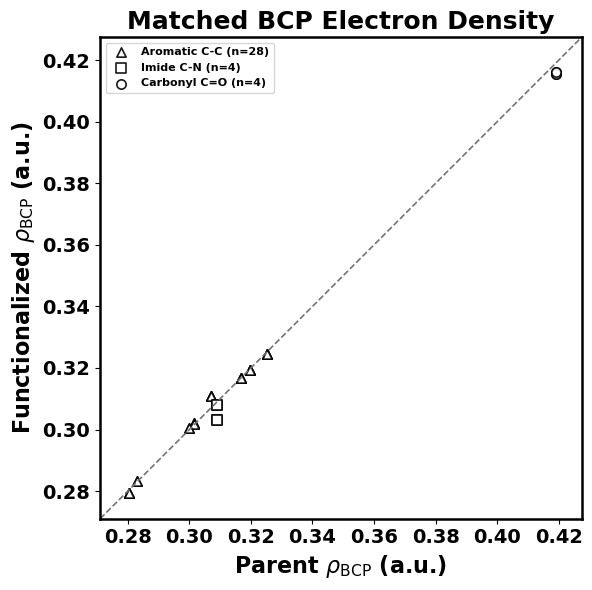

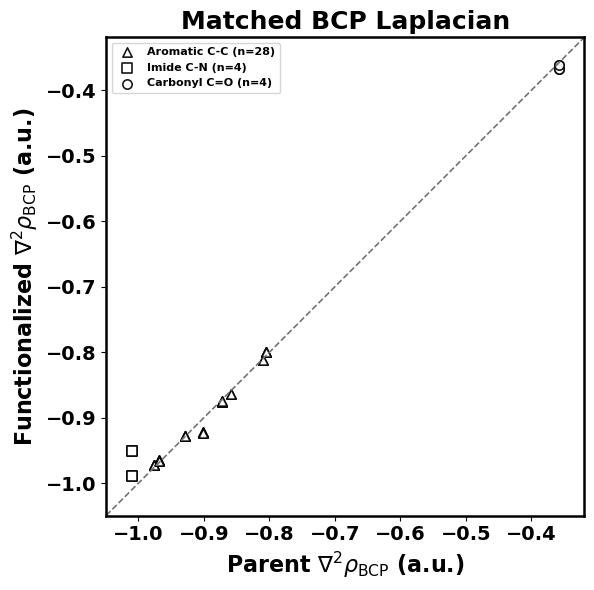

In [11]:
BCP_MARKERS = {
    "Carbonyl C=O": "o",
    "Imide C-N": "s",
    "Aromatic C-C": "^",
    "Other shared-core bond": "X",
}


def save_qtaim_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(QTAIM_FIGURES / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(QTAIM_FIGURES / f"{stem}.png", dpi=300, bbox_inches="tight")


def equal_axis_limits(x_values: pd.Series, y_values: pd.Series, padding_fraction: float = 0.06) -> tuple[float, float]:
    finite_values = pd.concat([x_values, y_values]).dropna().to_numpy(dtype=float)
    lower = float(np.min(finite_values))
    upper = float(np.max(finite_values))
    padding = padding_fraction * (upper - lower if upper > lower else 1.0)
    return lower - padding, upper + padding


def style_matched_bcp_axis(
    fig: plt.Figure,
    ax: plt.Axes,
    tick_fontsize: int = 14,
) -> None:
    style_white_axes(fig, ax)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontsize(tick_fontsize)
        tick_label.set_fontweight("bold")


def plot_matched_scatter(
    parent_column: str,
    functionalized_column: str,
    xlabel: str,
    ylabel: str,
    title: str,
    stem: str,
) -> None:
    fig, ax = plt.subplots(facecolor="white", figsize=(6.4, 6.0))

    for bond_class, group in matched_bcp_comparison.groupby("bond_class", sort=False):
        ax.scatter(
            group[parent_column],
            group[functionalized_column],
            s=45,
            marker=BCP_MARKERS.get(bond_class, "o"),
            facecolor="white",
            edgecolor="black",
            linewidth=1.2,
            alpha=0.90,
            label=f"{bond_class} (n={len(group)})",
        )

    lower, upper = equal_axis_limits(
        matched_bcp_comparison[parent_column],
        matched_bcp_comparison[functionalized_column],
    )
    ax.plot([lower, upper], [lower, upper], color="0.45", linestyle="--", linewidth=1.2)
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel, fontsize=16, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=16, fontweight="bold")
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.legend(frameon=True, prop={"size": 8, "weight": "bold"})
    style_matched_bcp_axis(fig, ax)
    fig.tight_layout()
    save_qtaim_figure(fig, stem)
    plt.show()


plot_matched_scatter(
    "parent_density_of_all_electrons",
    "functionalized_density_of_all_electrons",
    r"Parent $\rho_\mathrm{BCP}$ (a.u.)",
    r"Functionalized $\rho_\mathrm{BCP}$ (a.u.)",
    "Matched BCP Electron Density",
    "matched_bcp_electron_density_scatter",
)

plot_matched_scatter(
    "parent_laplacian_of_electron_density",
    "functionalized_laplacian_of_electron_density",
    r"Parent $\nabla^2\rho_\mathrm{BCP}$ (a.u.)",
    r"Functionalized $\nabla^2\rho_\mathrm{BCP}$ (a.u.)",
    "Matched BCP Laplacian",
    "matched_bcp_laplacian_scatter",
)


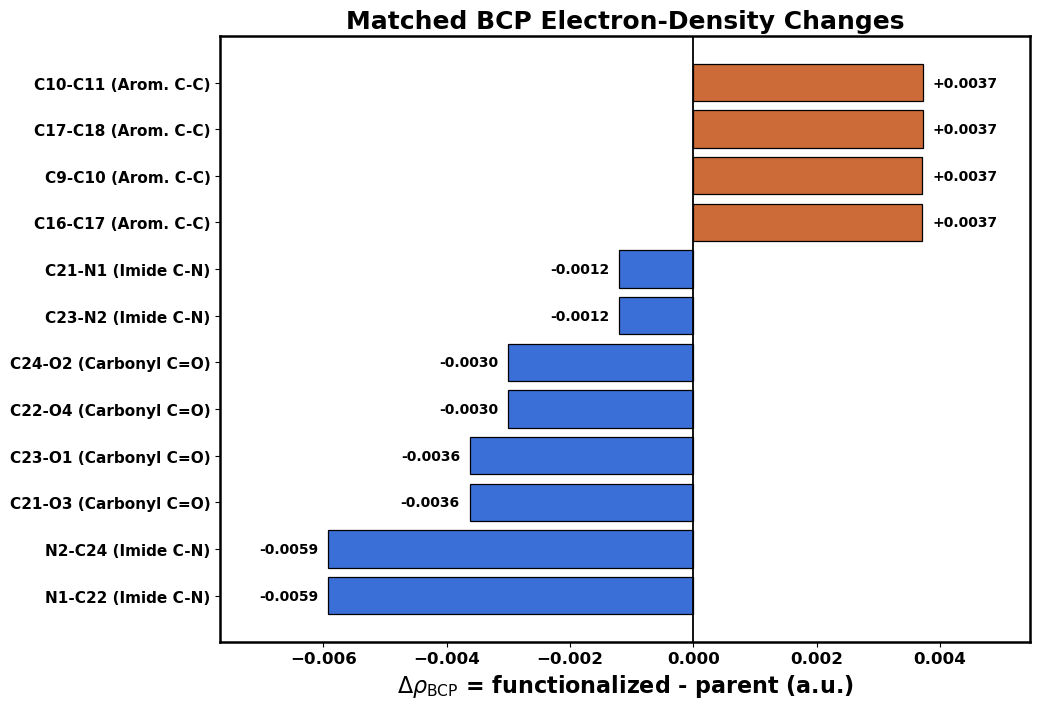

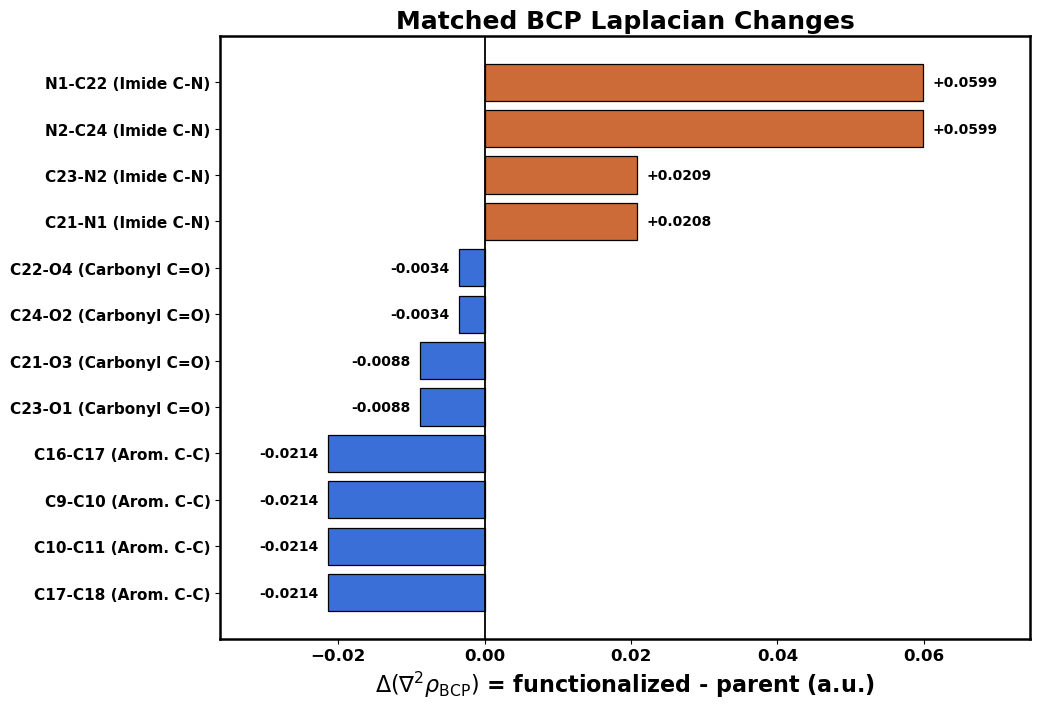

,bond_class,sample_size,mean_delta_rho_bcp,std_delta_rho_bcp,mean_delta_laplacian_bcp,std_delta_laplacian_bcp,mean_delta_bond_length_angstrom,std_delta_bond_length_angstrom
0,Aromatic C-C,28,0.000337,0.001528,-0.001850,0.008805,-0.000610,0.002270
1,Carbonyl C=O,4,-0.003320,0.000357,-0.006130,0.003114,0.003056,0.000317
2,Imide C-N,4,-0.003569,0.002727,0.040356,0.022533,0.009832,0.004628


In [12]:
def select_change_rows(delta_column: str) -> pd.DataFrame:
    ranked = matched_bcp_comparison.assign(
        absolute_delta=matched_bcp_comparison[delta_column].abs()
    ).sort_values("absolute_delta", ascending=False)

    chemically_required = ranked[
        ranked["bond_class"].isin(["Carbonyl C=O", "Imide C-N"])
    ]
    class_balanced = ranked.groupby("bond_class", group_keys=False).head(4)
    global_top = ranked.head(8)

    selected = (
        pd.concat([chemically_required, class_balanced, global_top], ignore_index=True)
        .drop_duplicates("bond_id")
        .sort_values(delta_column)
        .reset_index(drop=True)
    )
    return selected


def plot_change_bars(
    delta_column: str,
    xlabel: str,
    title: str,
    stem: str,
) -> None:
    plot_df = select_change_rows(delta_column)
    y = np.arange(len(plot_df))
    values = plot_df[delta_column].to_numpy(dtype=float)
    colors = np.where(values >= 0, "#cc6b38", "#3b6fd8")

    fig, ax = plt.subplots(facecolor="white", figsize=(10.5, 7.2))
    ax.barh(
        y,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.9,
    )
    ax.axvline(0, color="black", linewidth=1.3)
    class_label_short = {
        "Aromatic C-C": "Arom. C-C",
        "Imide C-N": "Imide C-N",
        "Carbonyl C=O": "Carbonyl C=O",
        "Other shared-core bond": "other",
    }
    ytick_labels = (
        plot_df["canonical_bond_label"]
        + " ("
        + plot_df["bond_class"].map(class_label_short).fillna(plot_df["bond_class"])
        + ")"
    )
    ax.set_yticks(y)
    ax.set_yticklabels(ytick_labels)

    value_min = min(float(np.nanmin(values)), 0.0)
    value_max = max(float(np.nanmax(values)), 0.0)
    value_span = max(value_max - value_min, 1.0e-4)
    horizontal_padding = 0.18 * value_span
    ax.set_xlim(value_min - horizontal_padding, value_max + horizontal_padding)

    for y_pos, value in zip(y, values, strict=True):
        is_positive = value >= 0
        ax.annotate(
            f"{value:+.4f}",
            xy=(value, y_pos),
            xytext=(7 if is_positive else -7, 0),
            textcoords="offset points",
            va="center",
            ha="left" if is_positive else "right",
            fontsize=10,
            fontweight="bold",
            color="black",
            clip_on=False,
        )

    ax.set_xlabel(xlabel, fontsize=16, fontweight="bold")
    ax.set_title(title, fontsize=18, fontweight="bold")
    style_matched_bcp_axis(fig, ax, tick_fontsize=11)
    ax.tick_params(axis="x", labelsize=12)
    fig.tight_layout()
    save_qtaim_figure(fig, stem)
    plt.show()


plot_change_bars(
    "delta_rho_bcp",
    r"$\Delta\rho_\mathrm{BCP}$ = functionalized - parent (a.u.)",
    "Matched BCP Electron-Density Changes",
    "matched_bcp_density_changes",
)

plot_change_bars(
    "delta_laplacian_bcp",
    r"$\Delta(\nabla^2\rho_\mathrm{BCP})$ = functionalized - parent (a.u.)",
    "Matched BCP Laplacian Changes",
    "matched_bcp_laplacian_changes",
)

class_summary = (
    matched_bcp_comparison.groupby("bond_class")
    .agg(
        sample_size=("bond_id", "count"),
        mean_delta_rho_bcp=("delta_rho_bcp", "mean"),
        std_delta_rho_bcp=("delta_rho_bcp", "std"),
        mean_delta_laplacian_bcp=("delta_laplacian_bcp", "mean"),
        std_delta_laplacian_bcp=("delta_laplacian_bcp", "std"),
        mean_delta_bond_length_angstrom=("delta_bond_length_angstrom", "mean"),
        std_delta_bond_length_angstrom=("delta_bond_length_angstrom", "std"),
    )
    .reset_index()
)

class_summary.to_csv(
    RESULTS / "qtaim" / "matched_bcp_class_summary.csv",
    index=False,
    float_format="%.17g",
)

display(class_summary)


In [13]:
summary_rows = []

for system in SYSTEM_ORDER:
    subset = bond_cps[bond_cps["system"] == system]
    row = {"system": system, "bond_cp_count": len(subset)}

    for c in available:
        values = pd.to_numeric(subset[c], errors="coerce")
        row.update(
            {
                f"{c}_mean": values.mean(),
                f"{c}_median": values.median(),
                f"{c}_minimum": values.min(),
                f"{c}_maximum": values.max(),
            }
        )

    summary_rows.append(row)

qtaim_summary = pd.DataFrame(summary_rows)
qtaim_summary.to_csv(RESULTS / "qtaim" / "qtaim_bcp_summary.csv", index=False)
qtaim_summary


,system,bond_cp_count,density_of_all_electrons_mean,density_of_all_electrons_median,density_of_all_electrons_minimum,density_of_all_electrons_maximum,laplacian_of_electron_density_mean,laplacian_of_electron_density_median,laplacian_of_electron_density_minimum,laplacian_of_electron_density_maximum,...,electron_localization_function_elf_minimum,electron_localization_function_elf_maximum,localized_orbital_locator_lol_mean,localized_orbital_locator_lol_median,localized_orbital_locator_lol_minimum,localized_orbital_locator_lol_maximum,sign_lambda2_rho_mean,sign_lambda2_rho_median,sign_lambda2_rho_minimum,sign_lambda2_rho_maximum
0,pdi,48,0.302042,0.307185,0.014500,0.418991,-0.885756,-0.929244,-1.826633,0.052721,...,0.046551,0.991514,0.770106,0.810063,0.181106,0.915343,-0.302042,-0.307185,-0.418991,-0.014500
1,pdi_terminal_functionalized,84,0.267598,0.282468,0.012592,0.415979,-0.780080,-0.931818,-1.053032,0.098467,...,0.031899,0.991493,0.759666,0.829116,0.153755,0.915249,-0.267598,-0.282468,-0.415979,-0.012592
